In [118]:
import numpy as np
from matplotlib import dates as mdates
import matplotlib.pyplot as plt
plt.rcParams["date.converter"] = "concise"

import pandas as pd
import glob

## BUBBLES

In [119]:
#path = '/home/karina/New_bubbles/'
path = '/fp/projects01/ec332/data/'
   
# combine the csvs 
#files = np.sort(glob.glob(path + 'detections/*.csv'))
#df0 = []
#for fil in files:
#    df0.append(pd.read_csv(fil))

#df = pd.concat(df0, ignore_index=True)
#df['day'] = df.time.str.split('T', n=1, expand=True)[0]
#df.to_csv(path + 'detections/all.csv', index=False)
df_bub =  pd.read_csv(path + 'detections/all.csv')

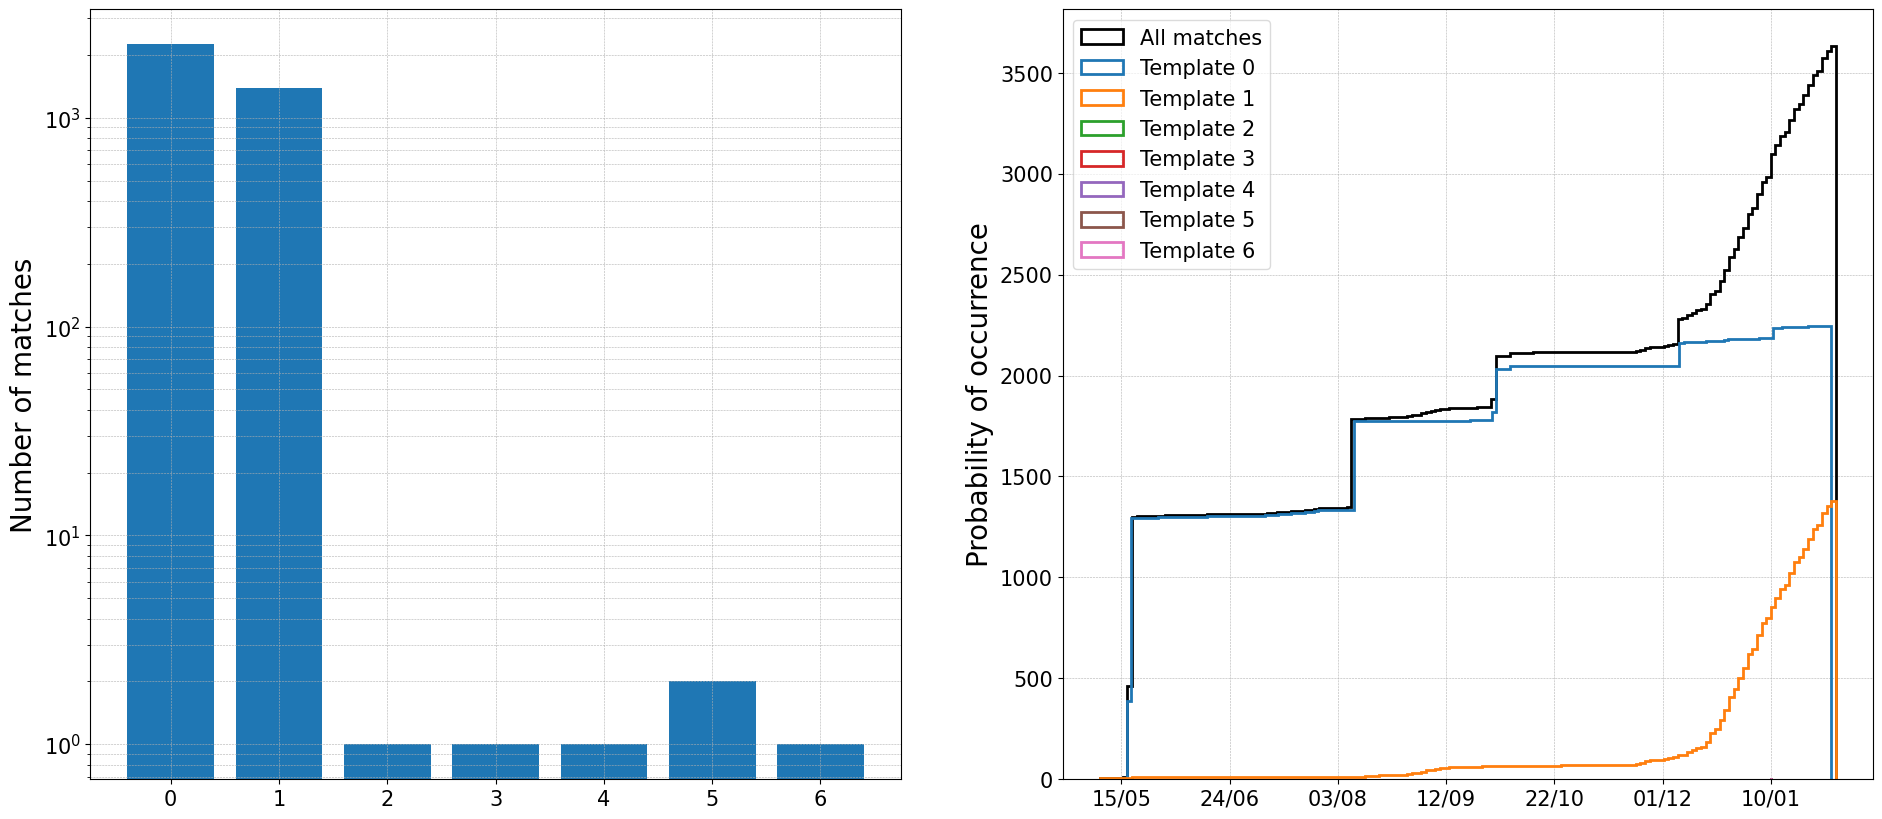

In [120]:
df_bub.day = pd.to_datetime(df_bub['day'], format='%Y-%m-%d')

figs, axs = plt.subplots(1,2, figsize=(23, 10))
axs1 = axs[0] 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
templU, templN = np.unique(df_bub.template_id, return_counts=True)
axs1.bar(templU, templN)
axs1.set_yscale('log')
#axs2.set_xscale('log') 
axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)

axs1 = axs[1] 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
data = df_bub.day.values
n_bins = len(df_bub['day'].unique())
n, bins, patches = axs1.hist(data, n_bins, 
#                 density=True, 
                 histtype="step",
                 cumulative=True, 
                 linewidth=2, color='k', label="All matches")

for it in templU:
    data = df_bub.day[df_bub.template_id==it].values
    n, bins, patches = axs1.hist(data, n_bins, 
#                     density=True, 
                     histtype="step",
                     cumulative=True, linewidth=2, label="Template "+str(it))    

date_form = mdates.DateFormatter("%d/%m")
axs1.xaxis.set_major_formatter(date_form)
axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))

#axs1.set_yscale('log')

axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)
axs1.set_ylabel('Probability of occurrence', fontsize = 20)
axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')

### OTHER EVENTS

In [121]:
#path = '/home/karina/New_bubbles/'
path = '/fp/projects01/ec332/data/'
   
# combine the csvs 
#files = np.sort(glob.glob(path + 'event_detections/*.csv'))
#df0 = []
#for fil in files:
#    df0.append(pd.read_csv(fil))

#df = pd.concat(df0, ignore_index=True)
#df['day'] = df.time.str.split('T', n=1, expand=True)[0]
#df.to_csv(path + 'event_detections/all.csv', index=False)
df =  pd.read_csv(path + 'event_detections/all.csv')

In [122]:
np.unique(df.template_type, return_counts=True)

(array(['ChirpA1', 'ChirpA2', 'ChirpB', 'Earthquake', 'Tremor1', 'Tremor2',
        'Tremor3', 'Tremor4'], dtype=object),
 array([4959, 5223, 2653,    5,    3,    3,  220,    5]))

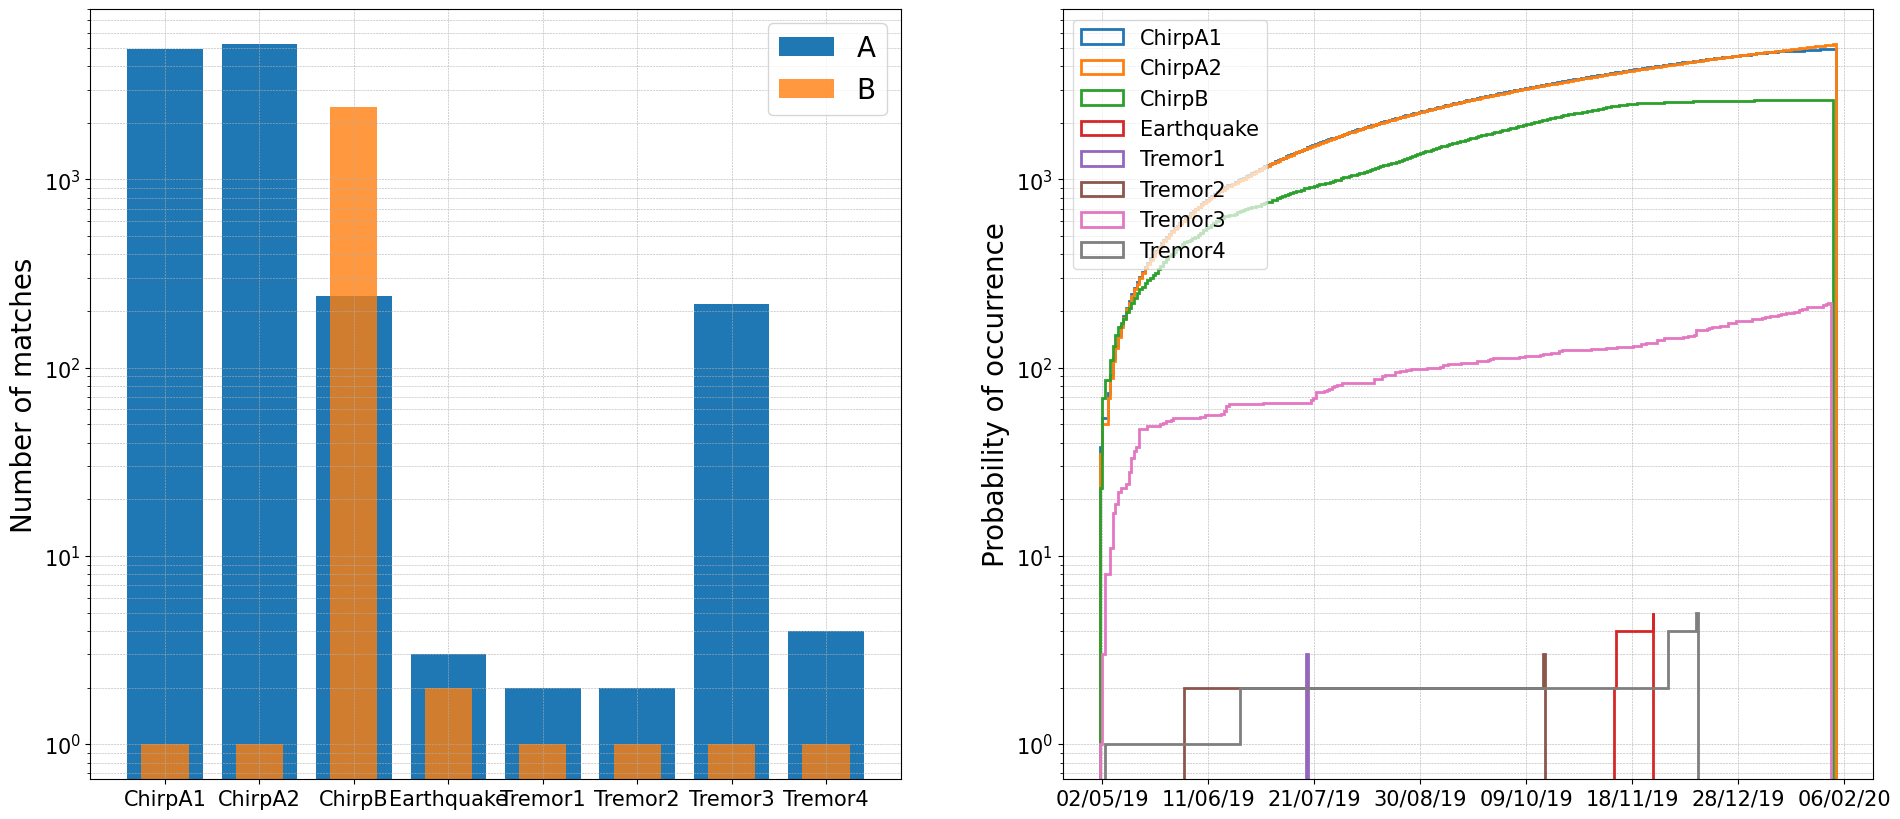

In [123]:
df.day = pd.to_datetime(df['day'], format='%Y-%m-%d')

figs, axs = plt.subplots(1,2, figsize=(23, 10))
axs1 = axs[0] 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
# A
templU, templN = np.unique(df.template_type[df.Channel=='A'], return_counts=True)
axs1.bar(templU, templN, label='A')
templU, templN = np.unique(df.template_type[df.Channel=='B'], return_counts=True)
axs1.bar(templU, templN, width=0.5, alpha = 0.8, label='B')
axs1.set_yscale('log')
#axs2.set_xscale('log') 
axs1.legend(fontsize = 20) 
axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)


templU, templN = np.unique(df.template_type, return_counts=True)
axs1 = axs[1] 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
data = df.day.values
n_bins = len(df['day'].unique())
#n, bins, patches = axs1.hist(data, n_bins, 
#                 density=True, 
#                 histtype="step",
#                 cumulative=True, 
#                 linewidth=2, color='k', label="All matches")

for it in templU:
    data = df.day[df.template_type==it].values
    n, bins, patches = axs1.hist(data, n_bins, 
#                     density=True, 
                     histtype="step",
                     cumulative=True, linewidth=2, label=str(it))    

date_form = mdates.DateFormatter("%d/%m/%y")
axs1.xaxis.set_major_formatter(date_form)
axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))

axs1.set_yscale('log')
#axs1.tick_params(labelsize = 15)  
axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)
axs1.set_ylabel('Probability of occurrence', fontsize = 20)
axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')

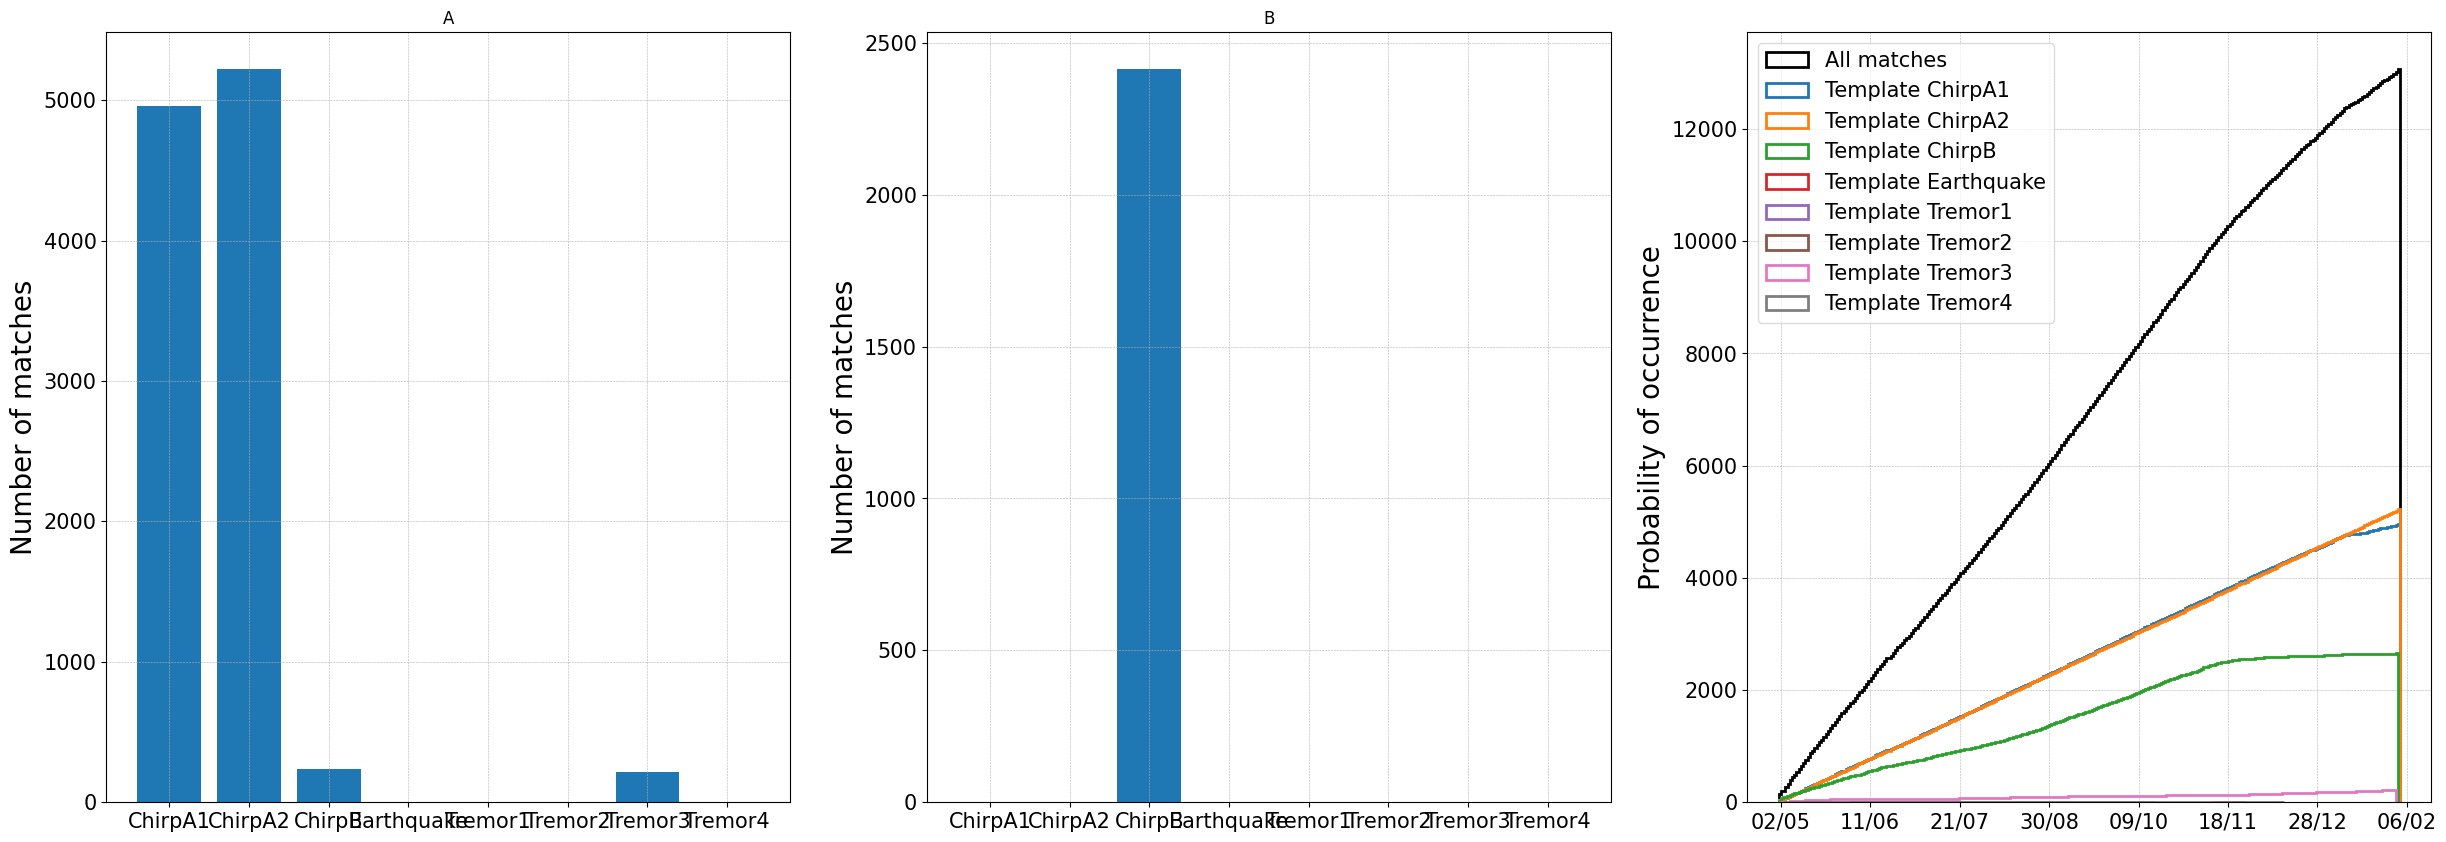

In [124]:
df.day = pd.to_datetime(df['day'], format='%Y-%m-%d')

figs, axs = plt.subplots(1,3, figsize=(30, 10))
axs1 = axs[0] 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
# A
templU, templN = np.unique(df.template_type[df.Channel=='A'], return_counts=True)
axs1.bar(templU, templN)
#templU, templN = np.unique(df.template_type[df.Channel=='B'], return_counts=True)
#axs1.bar(templU, templN)
#axs1.set_yscale('log')
#axs2.set_xscale('log') 
axs1.set_title('A') 
axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)

axs1 = axs[1] 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
# B
templU, templN = np.unique(df.template_type[df.Channel=='B'], return_counts=True)
axs1.bar(templU, templN)
#axs1.set_yscale('log')
axs1.set_title('B') 
axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)

templU, templN = np.unique(df.template_type, return_counts=True)
axs1 = axs[2] 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
data = df.day.values
n_bins = len(df['day'].unique())
n, bins, patches = axs1.hist(data, n_bins, 
#                 density=True, 
                 histtype="step",
                 cumulative=True, 
                 linewidth=2, color='k', label="All matches")

for it in templU:
    data = df.day[df.template_type==it].values
    n, bins, patches = axs1.hist(data, n_bins, 
#                     density=True, 
                     histtype="step",
                     cumulative=True, linewidth=2, label="Template "+str(it))    

date_form = mdates.DateFormatter("%d/%m")
axs1.xaxis.set_major_formatter(date_form)
axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))

#axs1.set_yscale('log')

axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)
axs1.set_ylabel('Probability of occurrence', fontsize = 20)
axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')

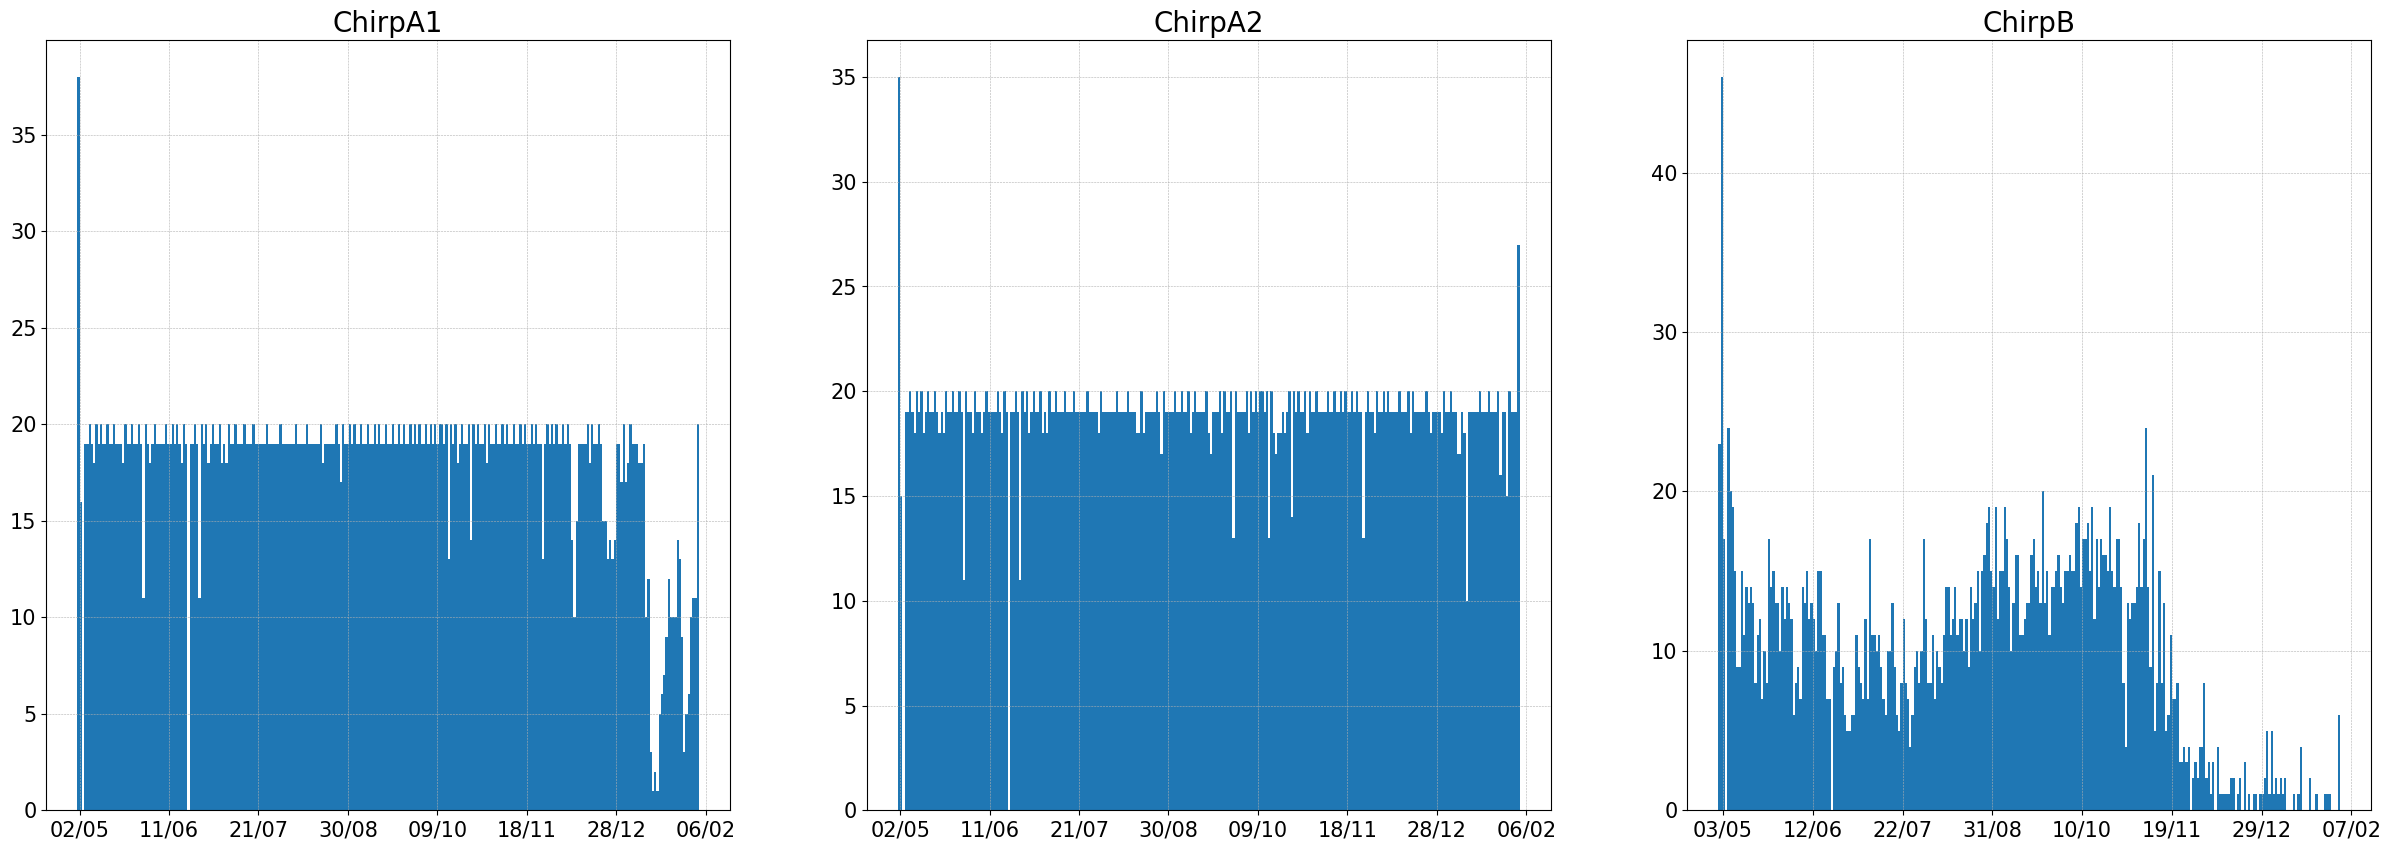

In [128]:
# check when in time the chirps happend 
df.day = pd.to_datetime(df['day'], format='%Y-%m-%d')

figs, axs = plt.subplots(1,3, figsize=(30, 10))
n_bins = len(df['day'].unique())
for it, tp in enumerate(['ChirpA1', 'ChirpA2', 'ChirpB']):
    axs1 = axs[it] 
    axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
    data = df.day[df.template_type==tp].values
    axs1.hist(data, n_bins, 
#                     density=True, 
                     histtype="bar",
                     #cumulative=True, 
                     linewidth=1)    

    date_form = mdates.DateFormatter("%d/%m")
    axs1.xaxis.set_major_formatter(date_form)
    axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))
    
    #axs1.set_yscale('log')
    
    axs1.tick_params(labelsize = 15)  
    axs1.set_title(tp, fontsize = 20)
    #axs1.set_ylabel('Probability of occurrence', fontsize = 20)
    #axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')

In [129]:
# Put the tremors together with the bubbles
df['template_type2'] = df['template_type'].copy().str[:-1]
df['template_type2'][df['template_type2']!='Tremor'] = df['template_type'].copy()[df['template_type2']!='Tremor']

/localscratch/1672568/ipykernel_3169936/2611876298.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['template_type2'][df['template_type2']!='Tremor'] = df['template_type'].copy()[df['template_type2']!='Tremor']


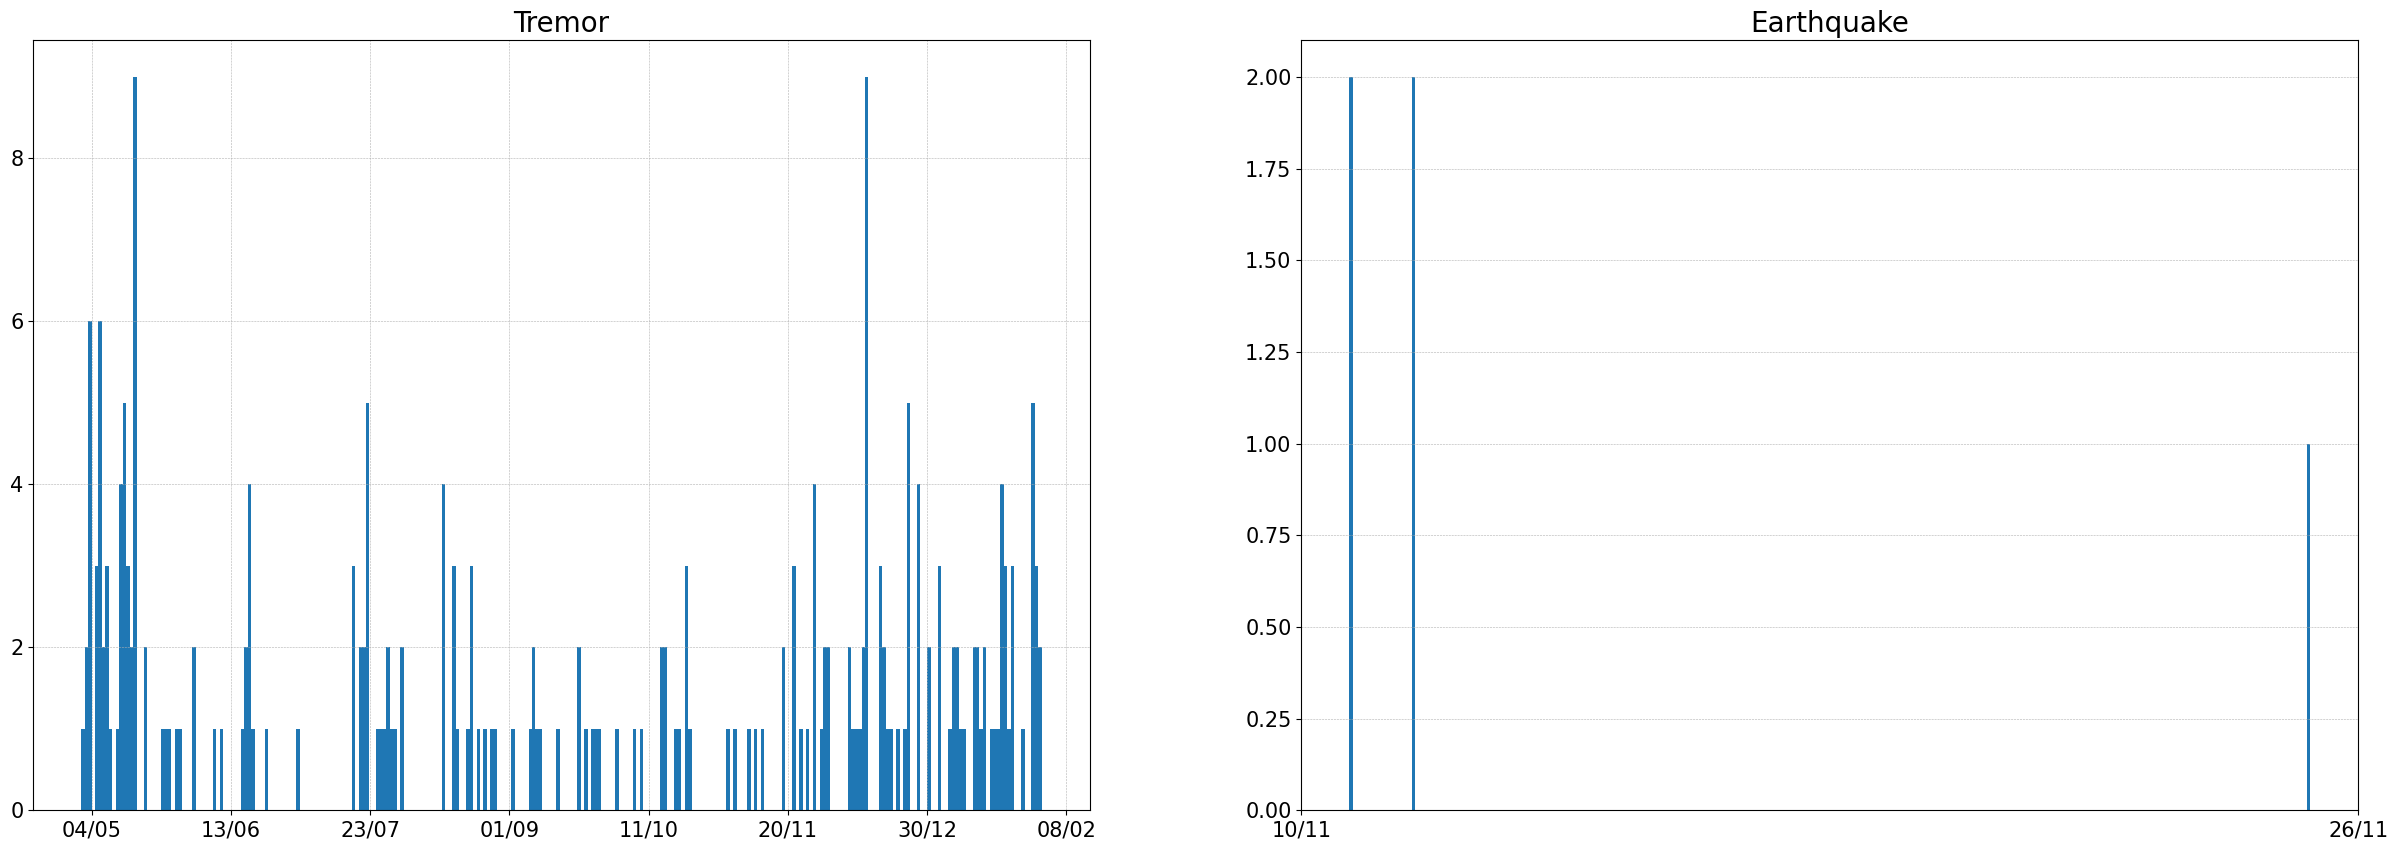

In [137]:
# check when in time the chirps happend 
df.day = pd.to_datetime(df['day'], format='%Y-%m-%d')

figs, axs = plt.subplots(1,2, figsize=(30, 10))
n_bins = len(df['day'].unique())
for it, tp in enumerate(['Tremor', 'Earthquake']):
    axs1 = axs[it] 
    axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
    data = df.day[df.template_type2==tp].values
    axs1.hist(data, n_bins, 
#                     density=True, 
                     histtype="bar",
                     #cumulative=True, 
                     linewidth=1)    

    date_form = mdates.DateFormatter("%d/%m")
    axs1.xaxis.set_major_formatter(date_form)
    axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))
    
    #axs1.set_yscale('log')
    
    axs1.tick_params(labelsize = 15)  
    axs1.set_title(tp, fontsize = 20)
    #axs1.set_ylabel('Probability of occurrence', fontsize = 20)
    #axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')

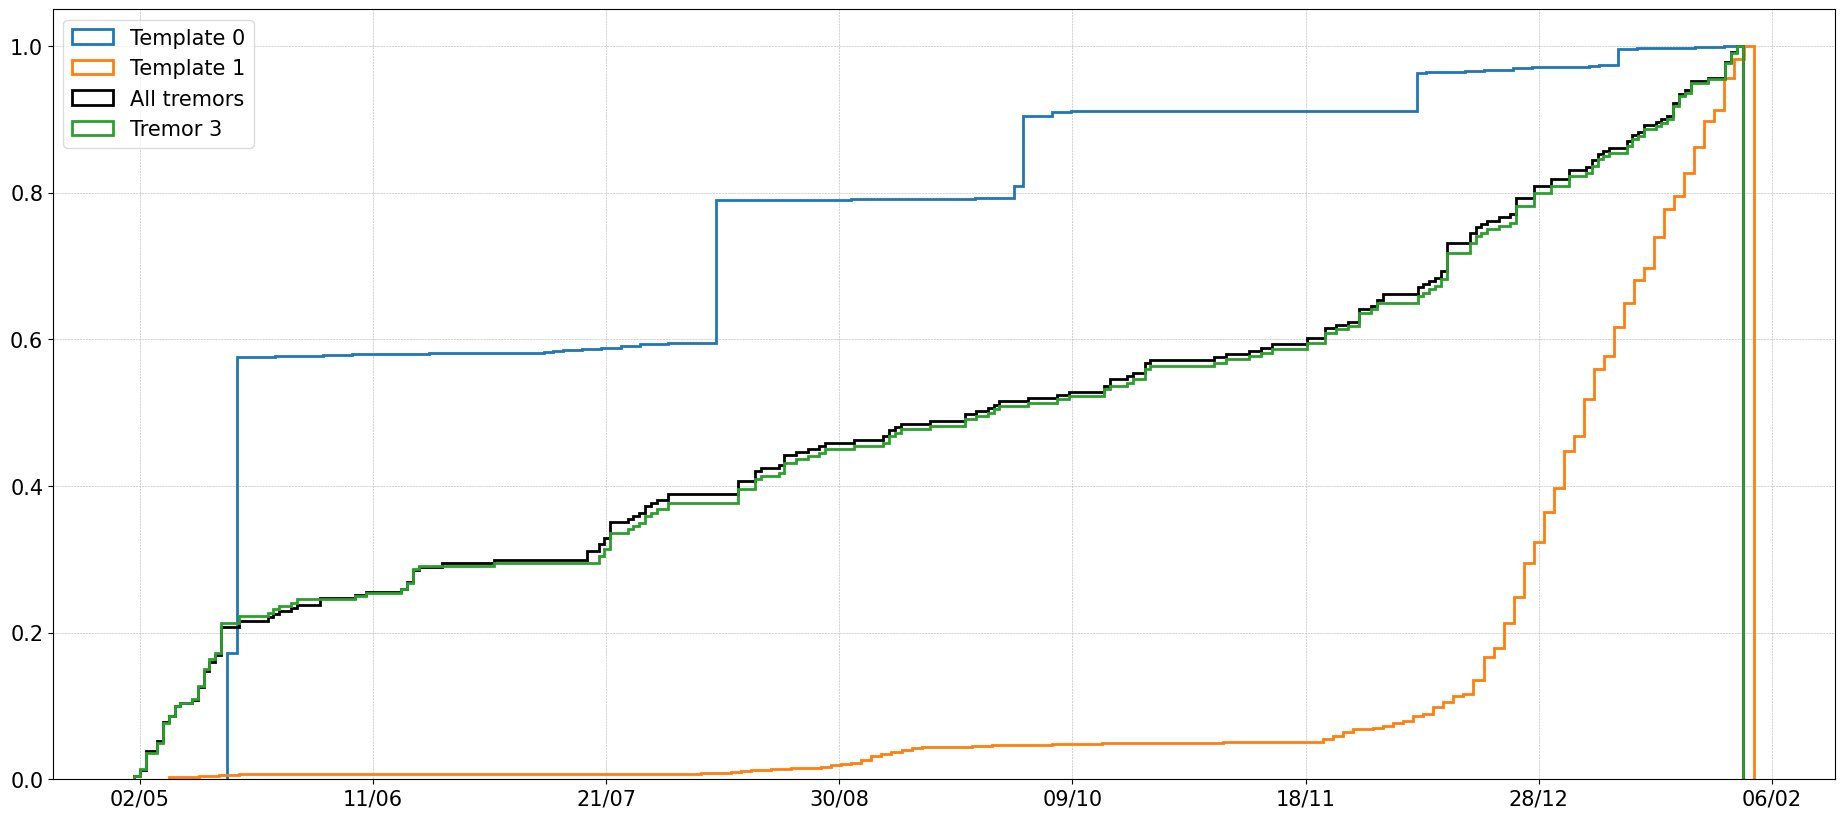

In [136]:
figs, axs1 = plt.subplots(figsize=(23, 10))
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)

#Bubbles
templU, templN = np.unique(df_bub.template_id, return_counts=True)
n_bins = len(df_bub['day'].unique())
for it in templU[:2]:
    data = df_bub.day[df_bub.template_id==it].values
    n, bins, patches = axs1.hist(data, n_bins, 
                     density=True, 
                     histtype="step",
                     cumulative=True, linewidth=2, label="Template "+str(it))    

# Tremors
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
data = df.day[df.template_type2=='Tremor'].values
n_bins = len(df['day'].unique())
n, bins, patches = axs1.hist(data, n_bins, 
                 density=True, 
                 histtype="step",
                 cumulative=True, 
                 linewidth=2, color='k', label="All tremors")

#for it in ['Tremor1', 'Tremor2','Tremor3', 'Tremor4']:
data = df.day[df.template_type=='Tremor3'].values
n, bins, patches = axs1.hist(data, n_bins, 
                 density=True, 
                 histtype="step",
                 cumulative=True, linewidth=2, label="Tremor 3")


date_form = mdates.DateFormatter("%d/%m")
axs1.xaxis.set_major_formatter(date_form)
axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))

#axs1.set_yscale('log')

axs1.tick_params(labelsize = 15)  
#axs1.set_ylabel('Number of matches', fontsize = 20)
#axs1.set_ylabel('Probability of occurrence', fontsize = 20)
axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')

In [131]:
np.unique(df['template_type2'], return_counts=True)

(array(['ChirpA1', 'ChirpA2', 'ChirpB', 'Earthquake', 'Tremor'],
       dtype=object),
 array([4959, 5223, 2653,    5,  231]))

In [132]:
# Compare to Clusters 
df_clust = pd.read_csv('window_clusters.csv')
df_clust['day'] = df_clust.window_start.str.split('T', n=1, expand=True)[0]
df_clust.day = pd.to_datetime(df_clust['day'], format='%Y-%m-%d')

clusters = np.unique(df_clust.cluster)
clusters

array(['A0', 'A1', 'B0', 'B1', 'C0', 'C1', 'C2', 'D0', 'D1', 'D2'],
      dtype=object)

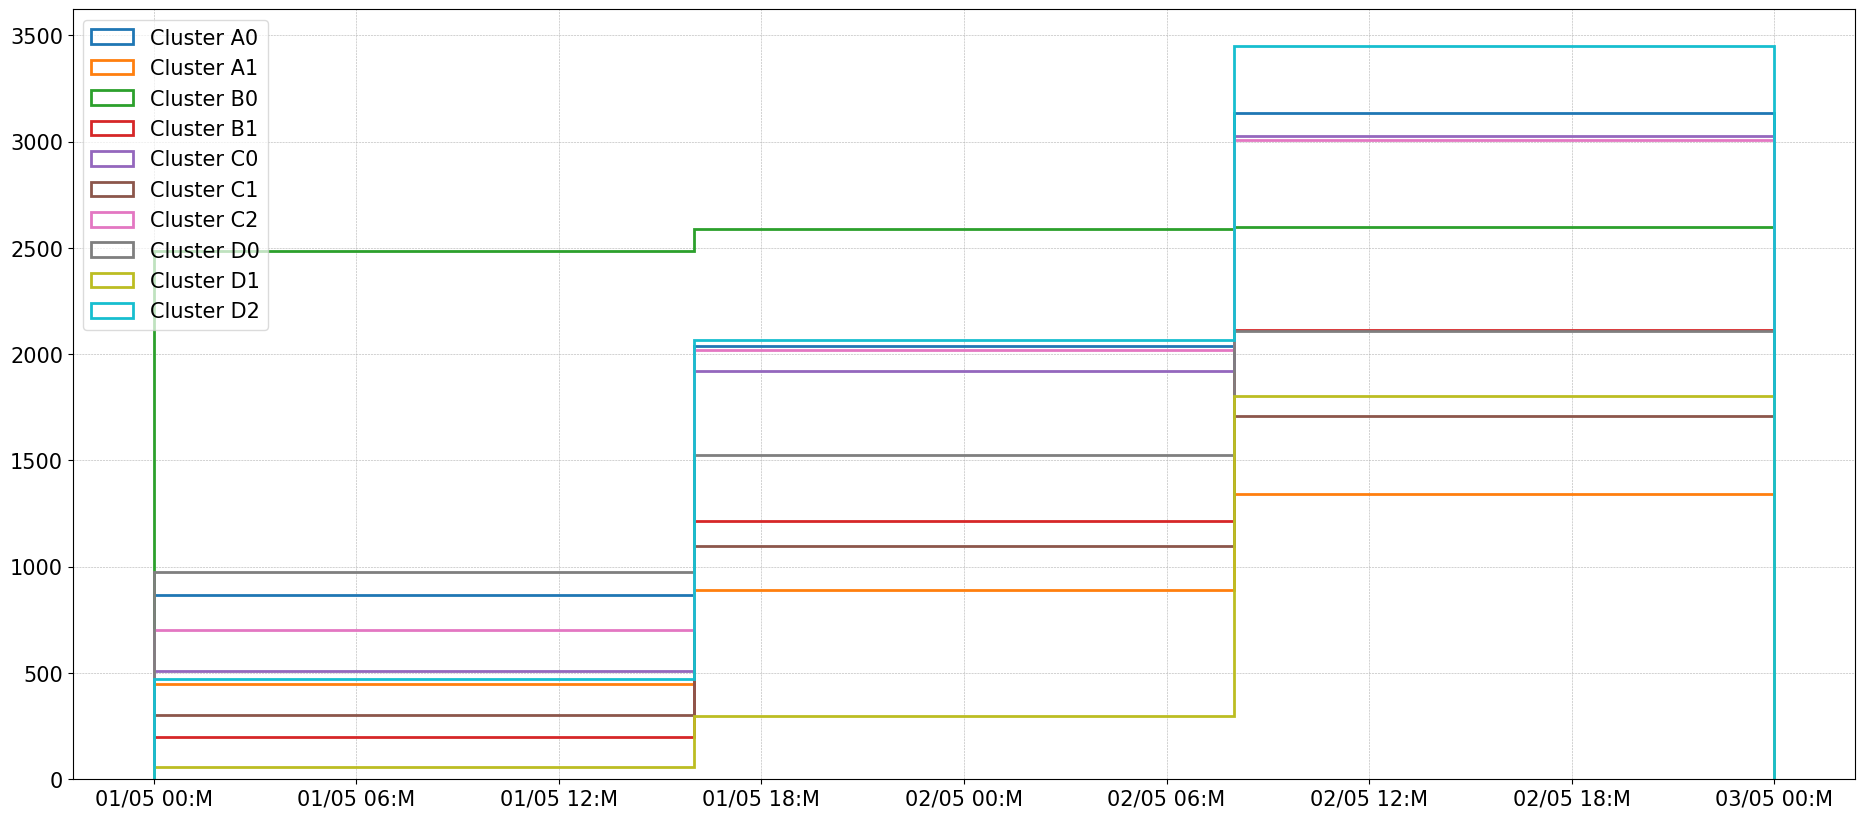

In [133]:
# Clusters 
figs, axs1 = plt.subplots(figsize=(23, 10))
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)

# Clusters 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
n_bins = len(df_clust['day'].unique())
for cl in clusters:
    data = df_clust.day[df_clust.cluster==cl].values
    n, bins, patches = axs1.hist(data, n_bins, 
                 #density=True, 
                 histtype="step",
                 cumulative=True, linewidth=2, label="Cluster "+cl)


date_form = mdates.DateFormatter("%d/%m %H:M")
axs1.xaxis.set_major_formatter(date_form)
#axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))

#axs1.set_yscale('log')

axs1.tick_params(labelsize = 15)  
#axs1.set_ylabel('Number of matches', fontsize = 20)
#axs1.set_ylabel('Probability of occurrence', fontsize = 20)
axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')


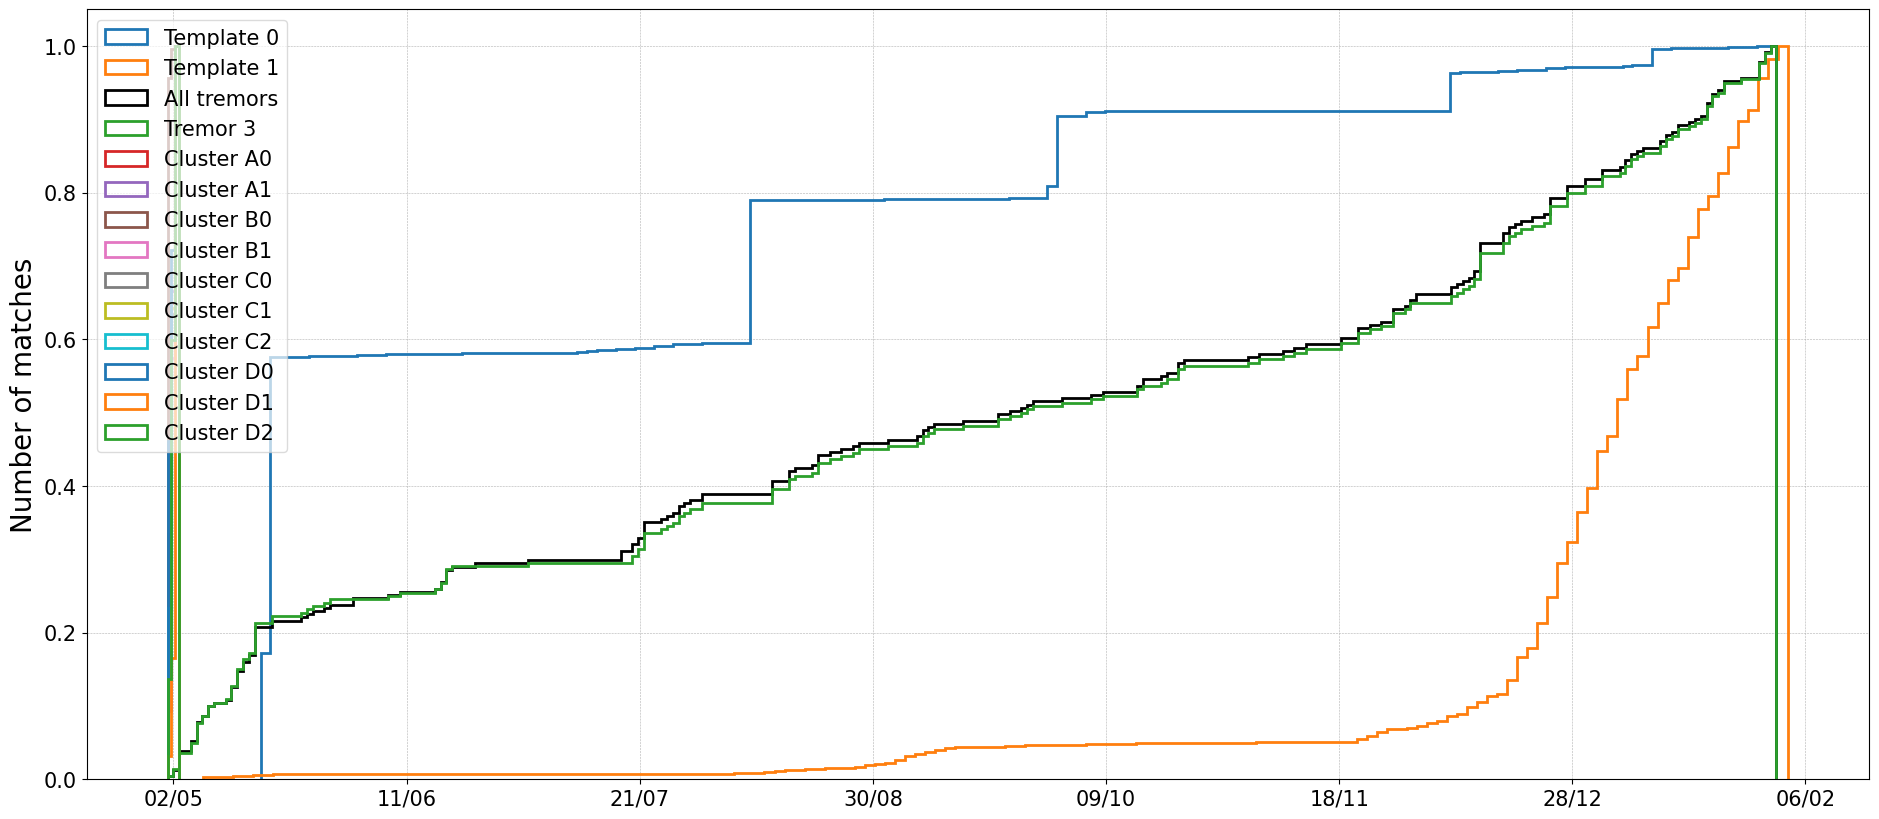

In [134]:
# Compare to Clusters 
figs, axs1 = plt.subplots(figsize=(23, 10))
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)

#Bubbles
templU, templN = np.unique(df_bub.template_id, return_counts=True)
n_bins = len(df_bub['day'].unique())
for it in templU[:2]:
    data = df_bub.day[df_bub.template_id==it].values
    n, bins, patches = axs1.hist(data, n_bins, 
                     density=True, 
                     histtype="step",
                     cumulative=True, linewidth=2, label="Template "+str(it))    

# Tremors
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
data = df.day[df.template_type2=='Tremor'].values
n_bins = len(df['day'].unique())
n, bins, patches = axs1.hist(data, n_bins, 
                 density=True, 
                 histtype="step",
                 cumulative=True, 
                 linewidth=2, color='k', label="All tremors")

#for it in ['Tremor1', 'Tremor2','Tremor3', 'Tremor4']:
data = df.day[df.template_type=='Tremor3'].values
n, bins, patches = axs1.hist(data, n_bins, 
                 density=True, 
                 histtype="step",
                 cumulative=True, linewidth=2, label="Tremor 3")

# Clusters 
axs1.grid(which='both', axis='both', linestyle='--', linewidth=0.4)
n_bins = len(df_clust['day'].unique())
for cl in clusters:
    data = df_clust.day[df_clust.cluster==cl].values
    n, bins, patches = axs1.hist(data, n_bins, 
                 density=True, 
                 histtype="step",
                 cumulative=True, linewidth=2, label="Cluster "+cl)


date_form = mdates.DateFormatter("%d/%m")
axs1.xaxis.set_major_formatter(date_form)
axs1.xaxis.set_major_locator(mdates.DayLocator(interval=40))

#axs1.set_yscale('log')

axs1.tick_params(labelsize = 15)  
axs1.set_ylabel('Number of matches', fontsize = 20)
#axs1.set_ylabel('Probability of occurrence', fontsize = 20)
axs1.legend(framealpha=0.7, fontsize=15, loc='upper left')


In [135]:
# Check if the templates and clusters coincide 



##  Workplan
 1) Scatter coefficients 
     1) Check that the scattering coefficients for 3days interval have worked
     2) Check effect of hyper-parameters: Pooling method, segment size
 
 2) Template matching
     1) Plot the bubbles, fractures and tremors (and earthquakes??) together and discuss if they are connected
     2) Also connect with the environemental plots
     3) Look more into the tremors
        1) Find out the length and energy content
        2) Improve template matching (use taper?, different filters?)


 3) UMAP and Hierarchical clustering
     1) Combine umap for several saved scatter coeffients 
     2) Fine-tune hyper parameters 
 
 4) Identify the signals
     1) Compare the clusters to the template-matched-catalog
     2) For each cluster calculate and plot the averaged first-order scattering coefficients and the normalized cumulative detentions
 
 5) Make a timeline and show the link to climate processes
     1)  Link to the other papers (Bubble, fracture and Tianze's paper)
   
 6) Write a paper? 